# 08 — Momentos de predicción y lags del rinde

Dos extensiones que pide la consigna, como **ablations** sobre el mejor modelo:

1. **Dos momentos del calendario agrícola** (`momento` en `datos.build_reg_dataset`):
   - `pre_siembra` — solo lo conocible antes de sembrar (ONI + humedad de suelo de
     invierno + estructurales). Sirve para decisiones tempranas.
   - `pre_cosecha` — clima y NDVI hasta febrero (sin marzo).
   - `full` — toda la campaña Sep–Mar (referencia).
2. **Lags del rinde** (`use_lags`): rinde de 1–k campañas previas + media móvil,
   todo con `shift` (nunca el año actual → sin leakage).

In [1]:
import sys, os, warnings
sys.path.insert(0, os.path.abspath('..'))
warnings.filterwarnings('ignore')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
import datos, evaluacion as ev, json
from modelos import XGBoostRegressor
CULTIVOS = ['soja', 'maiz']
_BEST = json.load(open('retuning_cv_honesta.json', encoding='utf-8')) if os.path.exists('retuning_cv_honesta.json') else {}
def evalua(cultivo, momento='full', use_lags=0, use_agro=None):
    if use_agro is None: use_agro = (momento == 'full')   # agro llega a marzo
    best = _BEST.get(cultivo, {}).get('xgb', {}).get('best_params', {})
    d = datos.prepare(cultivo, momento=momento, use_lags=use_lags, use_agro=use_agro, enc_smooth=10.0)
    m = XGBoostRegressor(**best, random_state=42).fit(d.X_train, d.y_train)
    p = m.predict(d.X_test)
    r = ev.metricas(d.y_test, p)
    r['skill'] = ev.skill_score(d.y_test, p, ev.pred_media_depto(d))
    r['n_feats'] = len(d.feature_cols)
    return r, d, p

## 1. Los tres momentos de predicción (soja y maíz)

In [2]:
filas, RESM = [], {}
for c in CULTIVOS:
    for mom in ['pre_siembra', 'pre_cosecha', 'full']:
        r, d, p = evalua(c, momento=mom)
        RESM[(c, mom)] = (d, p)
        filas.append({'cultivo': c, 'momento': mom, 'n_feats': r['n_feats'],
                      'RMSE': r['rmse'], 'R2': r['r2'], 'sMAPE': r['smape'], 'skill': r['skill']})
tabla_mom = pd.DataFrame(filas)
tabla_mom

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


,cultivo,momento,n_feats,RMSE,R2,sMAPE,skill
0,soja,pre_siembra,8,736.858,0.075,25.152,-0.040
1,soja,pre_cosecha,64,624.039,0.337,22.691,0.119
2,soja,full,78,606.071,0.374,22.039,0.144
3,maiz,pre_siembra,8,"1,990.093",0.016,28.875,-0.115
4,maiz,pre_cosecha,64,"1,712.844",0.271,27.181,0.041
5,maiz,full,78,"1,720.795",0.265,27.039,0.036


Cuanto más tarde en la campaña se predice, más información climática observada hay
→ mejor debería ser. `pre_siembra` es el caso más difícil (casi sin clima del año);
si aun así le gana a la climatología, hay señal anticipable (ENSO, humedad de suelo).

In [3]:
# ¿La diferencia full vs pre_cosecha es significativa? (mismas filas de test), por cultivo
for c in CULTIVOS:
    d_full, p_full = RESM[(c, 'full')]; d_pc, p_pc = RESM[(c, 'pre_cosecha')]
    dm = ev.diebold_mariano(d_full.y_test, p_full, p_pc, loss='se')
    print(f'{c}: DM full vs pre_cosecha = {dm["dm"]:.2f}  p={dm["p_value"]:.3f}  '
          f'-> {"significativa" if dm["p_value"] < 0.05 else "no significativa"}')

soja: DM full vs pre_cosecha = -5.09  p=0.000  -> significativa
maiz: DM full vs pre_cosecha = 1.60  p=0.110  -> no significativa


## 2. Lags del rinde (features autorregresivas), por cultivo

In [4]:
filas = []
for c in CULTIVOS:
    for k in [0, 1, 3, 5]:
        r, _, _ = evalua(c, momento='full', use_lags=k, use_agro=True)
        filas.append({'cultivo': c, 'lags': k, 'n_feats': r['n_feats'],
                      'RMSE': r['rmse'], 'R2': r['r2'], 'skill': r['skill']})
tabla_lags = pd.DataFrame(filas)
tabla_lags

[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)
[data] dedup panel: 27865 -> 20672 filas (7193 duplicados espurios por lat/lon eliminados)


,cultivo,lags,n_feats,RMSE,R2,skill
0,soja,0,78,606.071,0.374,0.144
1,soja,1,80,581.601,0.424,0.179
2,soja,3,82,577.012,0.433,0.185
3,soja,5,84,580.564,0.426,0.180
4,maiz,0,78,"1,720.795",0.265,0.036
5,maiz,1,80,"1,566.053",0.391,0.123
6,maiz,3,82,"1,551.251",0.402,0.131
7,maiz,5,84,"1,543.862",0.408,0.135


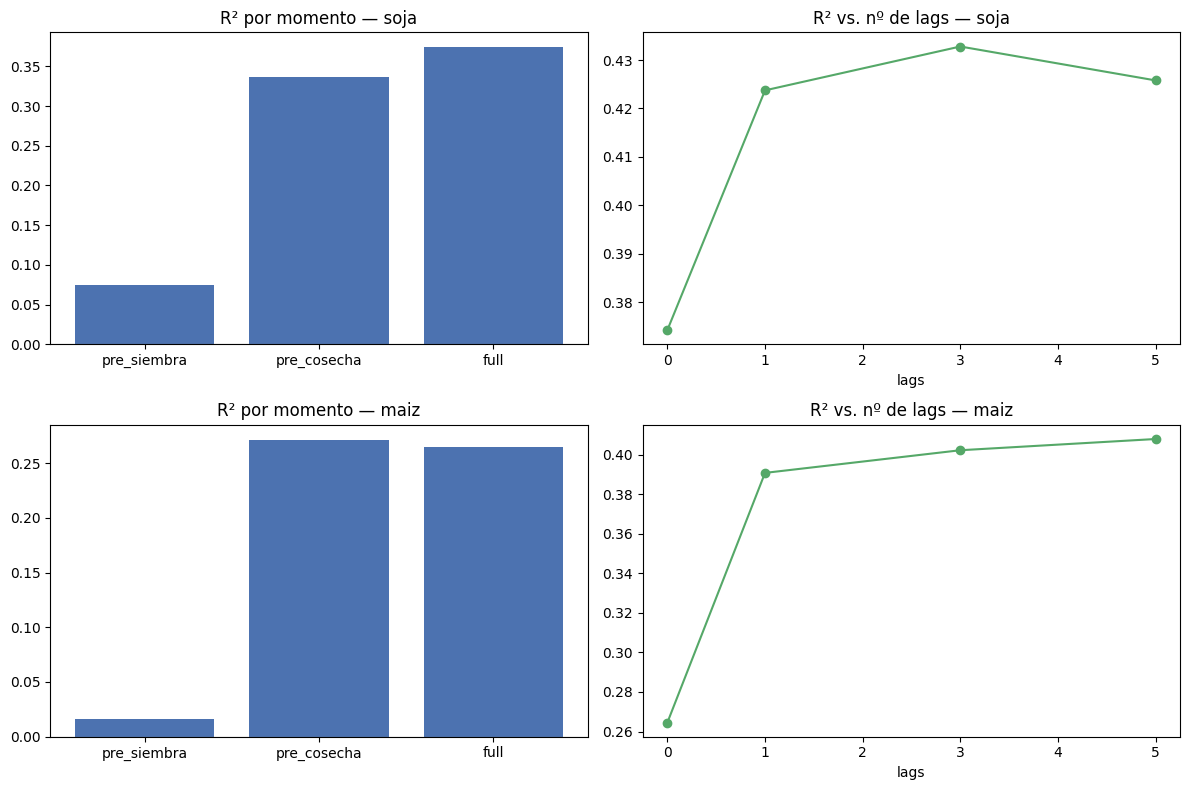

In [5]:
fig, axes = plt.subplots(len(CULTIVOS), 2, figsize=(12, 4 * len(CULTIVOS)))
for i, c in enumerate(CULTIVOS):
    tm = tabla_mom[tabla_mom.cultivo == c]; tl = tabla_lags[tabla_lags.cultivo == c]
    axes[i, 0].bar(tm['momento'], tm['R2'], color='#4C72B0'); axes[i, 0].axhline(0, color='0.6', lw=0.8)
    axes[i, 0].set_title(f'R² por momento — {c}')
    axes[i, 1].plot(tl['lags'], tl['R2'], marker='o', color='#55A868')
    axes[i, 1].set_title(f'R² vs. nº de lags — {c}'); axes[i, 1].set_xlabel('lags')
plt.tight_layout(); plt.show()

## Conclusión

- **Momentos:** `full` y `pre_cosecha` rinden parecido (el clima de marzo aporta
  poco una vez que están sep–feb y el NDVI); el Diebold–Mariano dice si la diferencia
  es real. `pre_siembra` es mucho más difícil — su skill vs. climatología mide cuánto
  se puede **anticipar** antes de sembrar (ENSO + humedad de suelo).
- **Lags:** agregar el rinde de campañas previas aporta señal autorregresiva
  (persistencia depto), complementaria al `depto_enc`. El punto óptimo de k se ve en
  la curva; más lags achican el train (se pierden las primeras campañas de cada serie).